In [1]:
!pip -q install ucimlrepo

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00519/heart_failure_clinical_records_dataset.csv"

df = pd.read_csv(url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (299, 13)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Number of rows: 299
Number of columns: 13

Data Types:
age                         float64
anaemia                       int64
creatinine_phosphokinase      int64
diabetes                      int64
ejection_fraction             int64
high_blood_pressure           int64
platelets                   float64
serum_creatinine            float64
serum_sodium                  int64
sex                           int64
smoking                       int64
time                          int64
DEATH_EVENT                   int64
dtype: object

Missing Values:
age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


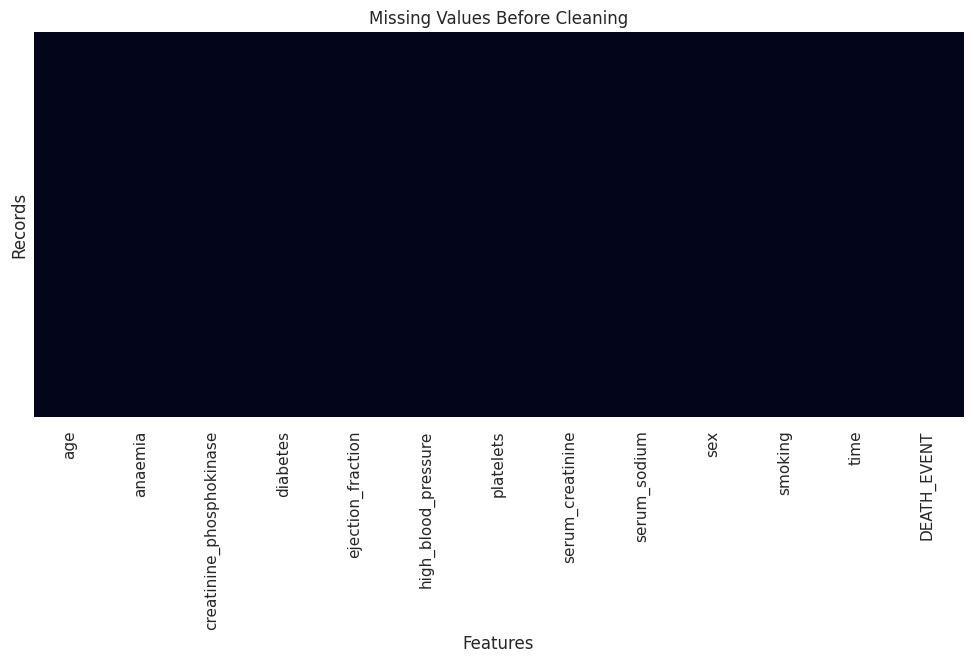

In [4]:
plt.figure(figsize=(12, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values Before Cleaning")
plt.xlabel("Features")
plt.ylabel("Records")
plt.show()

In [5]:
print("Basic Statistical Summary:")

display(df.describe())

Basic Statistical Summary:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
count,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.000000,299.00000,299.000000,299.000000,299.00000,299.000000,299.00000
mean,60.833893,0.431438,581.839465,0.418060,38.083612,0.351171,263358.029264,1.39388,136.625418,0.648829,0.32107,130.260870,0.32107
std,11.894809,0.496107,970.287881,0.494067,11.834841,0.478136,97804.236869,1.03451,4.412477,0.478136,0.46767,77.614208,0.46767
min,40.000000,0.000000,23.000000,0.000000,14.000000,0.000000,25100.000000,0.50000,113.000000,0.000000,0.00000,4.000000,0.00000
25%,51.000000,0.000000,116.500000,0.000000,30.000000,0.000000,212500.000000,0.90000,134.000000,0.000000,0.00000,73.000000,0.00000
50%,60.000000,0.000000,250.000000,0.000000,38.000000,0.000000,262000.000000,1.10000,137.000000,1.000000,0.00000,115.000000,0.00000
75%,70.000000,1.000000,582.000000,1.000000,45.000000,1.000000,303500.000000,1.40000,140.000000,1.000000,1.00000,203.000000,1.00000
max,95.000000,1.000000,7861.000000,1.000000,80.000000,1.000000,850000.000000,9.40000,148.000000,1.000000,1.00000,285.000000,1.00000


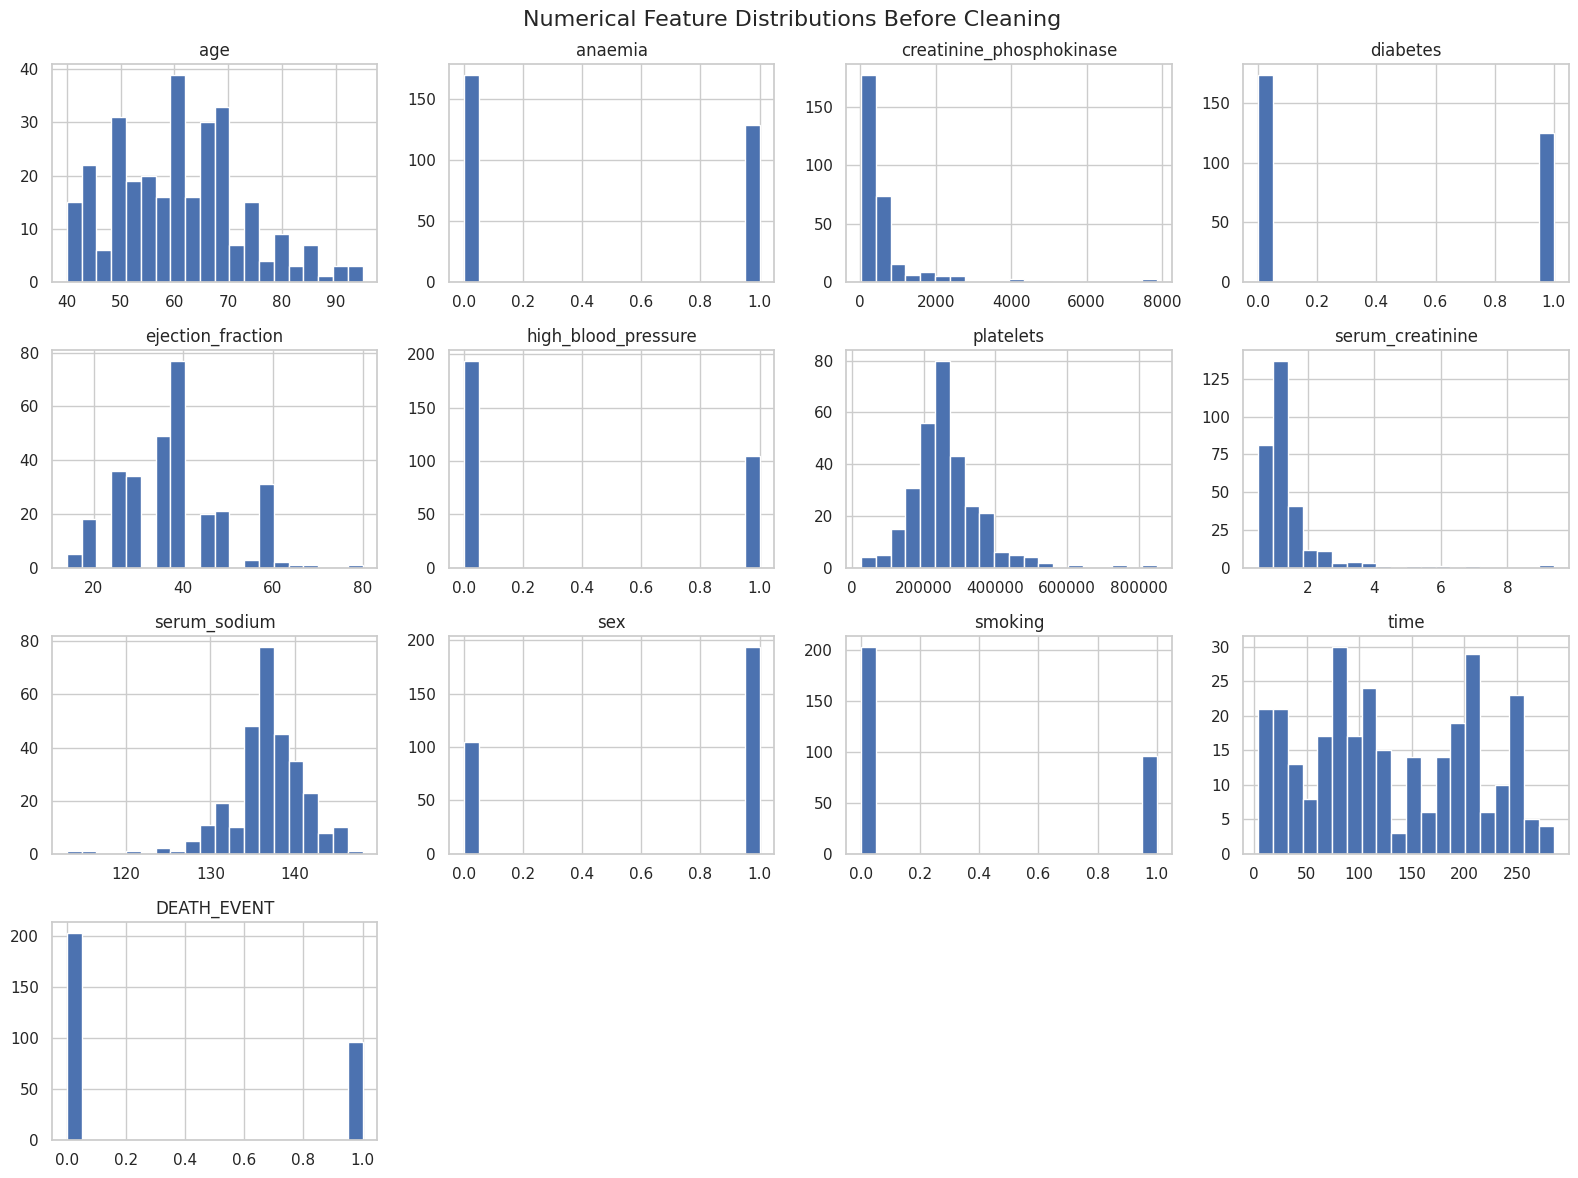

In [6]:
numerical_columns = df.select_dtypes(include=np.number).columns

df[numerical_columns].hist(
    figsize=(16, 12),
    bins=20
)

plt.suptitle(
    "Numerical Feature Distributions Before Cleaning",
    fontsize=16
)

plt.tight_layout()
plt.show()

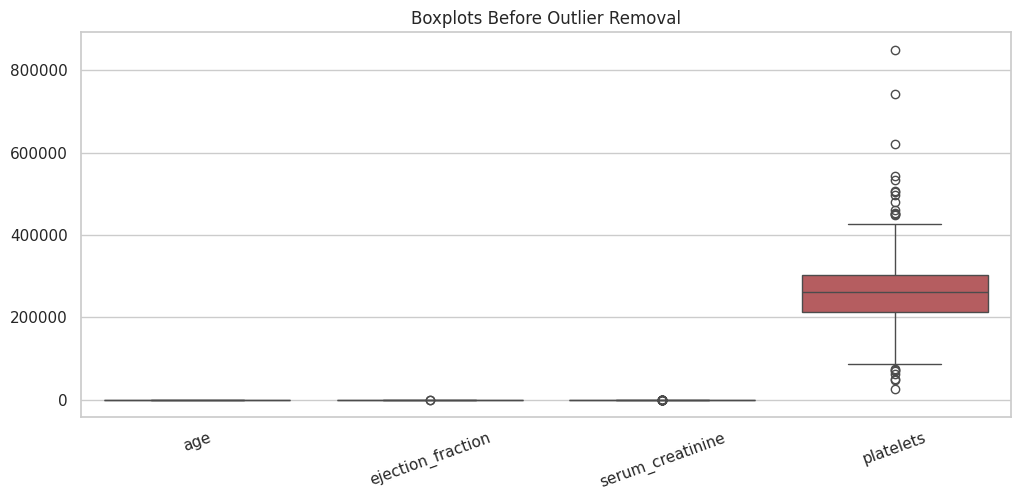

In [7]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df[
        [
            "age",
            "ejection_fraction",
            "serum_creatinine",
            "platelets"
        ]
    ]
)

plt.title("Boxplots Before Outlier Removal")
plt.xticks(rotation=20)

plt.show()

In [8]:
before_stats = df[numerical_columns].agg(
    ["mean", "median", "std"]
).T

print("Summary Statistics BEFORE Cleaning:")

display(before_stats)

Summary Statistics BEFORE Cleaning:


,mean,median,std
age,60.833893,60.0,11.894809
anaemia,0.431438,0.0,0.496107
creatinine_phosphokinase,581.839465,250.0,970.287881
diabetes,0.418060,0.0,0.494067
ejection_fraction,38.083612,38.0,11.834841
high_blood_pressure,0.351171,0.0,0.478136
platelets,263358.029264,262000.0,97804.236869
serum_creatinine,1.393880,1.1,1.034510
serum_sodium,136.625418,137.0,4.412477
sex,0.648829,1.0,0.478136


In [9]:
# Check for invalid ages

invalid_age = df["age"] <= 0

print("Number of invalid age values:", invalid_age.sum())

# Convert invalid ages into missing values
df.loc[invalid_age, "age"] = np.nan

print("\nInvalid ages have been converted to NaN.")

Number of invalid age values: 0

Invalid ages have been converted to NaN.


In [10]:
clinical_columns = [
    "ejection_fraction",
    "serum_creatinine",
    "platelets",
    "serum_sodium"
]

for column in clinical_columns:
    invalid = df[column] < 0
    print(f"{column}: {invalid.sum()} negative values")

    df.loc[invalid, column] = np.nan

ejection_fraction: 0 negative values
serum_creatinine: 0 negative values
platelets: 0 negative values
serum_sodium: 0 negative values


In [11]:
# missing-value imputation

np.random.seed(42)

rows = np.random.choice(
    df.index,
    size=10,
    replace=False
)

# Numerical missing values
df.loc[rows[:5], "serum_creatinine"] = np.nan

# Categorical/binary missing values
df.loc[rows[5:], "smoking"] = np.nan

print("Missing values before imputation:")

display(df.isnull().sum())

Missing values before imputation:


,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,5
serum_sodium,0
sex,0


Impute Missing Values

In [12]:
# Numerical feature: age
df["age"] = df["age"].fillna(
    df["age"].median()
)

# Numerical feature: serum_creatinine
df["serum_creatinine"] = df["serum_creatinine"].fillna(
    df["serum_creatinine"].median()
)

# Categorical/binary feature: smoking
df["smoking"] = df["smoking"].fillna(
    df["smoking"].mode()[0]
)

print("Missing values AFTER imputation:")

display(df.isnull().sum())

Missing values AFTER imputation:


,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0


Remove Outliers

In [13]:
def remove_outliers_iqr(data, columns):

    cleaned_data = data.copy()

    mask = pd.Series(
        True,
        index=cleaned_data.index
    )

    for column in columns:

        Q1 = cleaned_data[column].quantile(0.25)
        Q3 = cleaned_data[column].quantile(0.75)

        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        mask &= cleaned_data[column].between(
            lower_bound,
            upper_bound
        )

    return cleaned_data.loc[mask].copy()


outlier_columns = [
    "age",
    "ejection_fraction",
    "serum_creatinine",
    "platelets"
]

rows_before = len(df)

df_clean = remove_outliers_iqr(
    df,
    outlier_columns
)

rows_after = len(df_clean)

print("Rows before outlier removal:", rows_before)
print("Rows after outlier removal:", rows_after)
print("Rows removed:", rows_before - rows_after)

Rows before outlier removal: 299
Rows after outlier removal: 252
Rows removed: 47


Feature engineering

In [14]:
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[-np.inf, 40, 60, np.inf],
    labels=[
        "<40",
        "40-60",
        ">60"
    ],
    right=False
)

print("Age Group Distribution:")

display(
    df_clean["age_group"].value_counts()
)

Age Group Distribution:


,count
age_group,
>60,136
40-60,116
<40,0


Create Risk Score

In [15]:
# Normalize ejection_fraction
ef_min = df_clean["ejection_fraction"].min()
ef_max = df_clean["ejection_fraction"].max()

ef_normalized = (
    df_clean["ejection_fraction"] - ef_min
) / (
    ef_max - ef_min
)

# Normalize serum_creatinine
sc_min = df_clean["serum_creatinine"].min()
sc_max = df_clean["serum_creatinine"].max()

sc_normalized = (
    df_clean["serum_creatinine"] - sc_min
) / (
    sc_max - sc_min
)

# Product
product = ef_normalized * sc_normalized

# Normalize product to 0-1
product_min = product.min()
product_max = product.max()

df_clean["risk_score"] = (
    product - product_min
) / (
    product_max - product_min
)

display(
    df_clean[
        [
            "ejection_fraction",
            "serum_creatinine",
            "risk_score"
        ]
    ].head()
)

,ejection_fraction,serum_creatinine,risk_score
0,20.0,1.9,0.146341
1,38.0,1.1,0.250871
2,20.0,1.3,0.083624
3,20.0,1.9,0.146341
5,40.0,2.1,0.724739


Encoding categorical variables

In [16]:
df_clean = pd.get_dummies(
    df_clean,
    columns=["age_group"],
    drop_first=False,
    dtype=int
)

print("Dataset after encoding:")

display(df_clean.head())

print("\nFinal columns:")

print(df_clean.columns.tolist())

Dataset after encoding:


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_<40,age_group_40-60,age_group_>60
0,75.0,0,582,0,20.0,1,265000.00,1.9,130.0,1,0.0,4,1,0.146341,0,0,1
1,55.0,0,7861,0,38.0,0,263358.03,1.1,136.0,1,0.0,6,1,0.250871,0,1,0
2,65.0,0,146,0,20.0,0,162000.00,1.3,129.0,1,1.0,7,1,0.083624,0,0,1
3,50.0,1,111,0,20.0,0,210000.00,1.9,137.0,1,0.0,7,1,0.146341,0,1,0
5,90.0,1,47,0,40.0,1,204000.00,2.1,132.0,1,0.0,8,1,0.724739,0,0,1



Final columns:
['age', 'anaemia', 'creatinine_phosphokinase', 'diabetes', 'ejection_fraction', 'high_blood_pressure', 'platelets', 'serum_creatinine', 'serum_sodium', 'sex', 'smoking', 'time', 'DEATH_EVENT', 'risk_score', 'age_group_<40', 'age_group_40-60', 'age_group_>60']


Normalize numerical features

In [17]:
scale_columns = [
    "age",
    "creatinine_phosphokinase",
    "ejection_fraction",
    "platelets",
    "serum_creatinine",
    "serum_sodium",
    "risk_score"
]

scaler = MinMaxScaler()

df_clean[scale_columns] = scaler.fit_transform(
    df_clean[scale_columns]
)

print("Normalized Features:")

display(
    df_clean[scale_columns].head()
)

Normalized Features:


,age,creatinine_phosphokinase,ejection_fraction,platelets,serum_creatinine,serum_sodium,risk_score
0,0.636364,0.070489,0.117647,0.523529,0.875,0.485714,0.146341
1,0.272727,1.000000,0.470588,0.518700,0.375,0.657143,0.250871
2,0.454545,0.014813,0.117647,0.220588,0.500,0.457143,0.083624
3,0.181818,0.010344,0.117647,0.361765,0.875,0.685714,0.146341
5,0.909091,0.002171,0.509804,0.344118,1.000,0.542857,0.724739


In [18]:
numeric_after = df_clean.select_dtypes(
    include=np.number
).columns

after_stats = df_clean[
    numeric_after
].agg(
    ["mean", "median", "std"]
).T

print("Summary Statistics AFTER Cleaning:")

display(after_stats)

Summary Statistics AFTER Cleaning:


,mean,median,std
age,0.370659,0.363636,0.217078
anaemia,0.440476,0.000000,0.497432
creatinine_phosphokinase,0.071691,0.027902,0.128005
diabetes,0.412698,0.000000,0.493299
ejection_fraction,0.469032,0.470588,0.225869
high_blood_pressure,0.373016,0.000000,0.484569
platelets,0.497528,0.518174,0.201194
serum_creatinine,0.393998,0.375000,0.208576
serum_sodium,0.682653,0.685714,0.120277
sex,0.658730,1.000000,0.475079


Compare Before and After

In [19]:
print("BEFORE CLEANING")
display(before_stats)

print("\nAFTER CLEANING")
display(after_stats)

BEFORE CLEANING


,mean,median,std
age,60.833893,60.0,11.894809
anaemia,0.431438,0.0,0.496107
creatinine_phosphokinase,581.839465,250.0,970.287881
diabetes,0.418060,0.0,0.494067
ejection_fraction,38.083612,38.0,11.834841
high_blood_pressure,0.351171,0.0,0.478136
platelets,263358.029264,262000.0,97804.236869
serum_creatinine,1.393880,1.1,1.034510
serum_sodium,136.625418,137.0,4.412477
sex,0.648829,1.0,0.478136



AFTER CLEANING


,mean,median,std
age,0.370659,0.363636,0.217078
anaemia,0.440476,0.000000,0.497432
creatinine_phosphokinase,0.071691,0.027902,0.128005
diabetes,0.412698,0.000000,0.493299
ejection_fraction,0.469032,0.470588,0.225869
high_blood_pressure,0.373016,0.000000,0.484569
platelets,0.497528,0.518174,0.201194
serum_creatinine,0.393998,0.375000,0.208576
serum_sodium,0.682653,0.685714,0.120277
sex,0.658730,1.000000,0.475079


Validate Cleaning

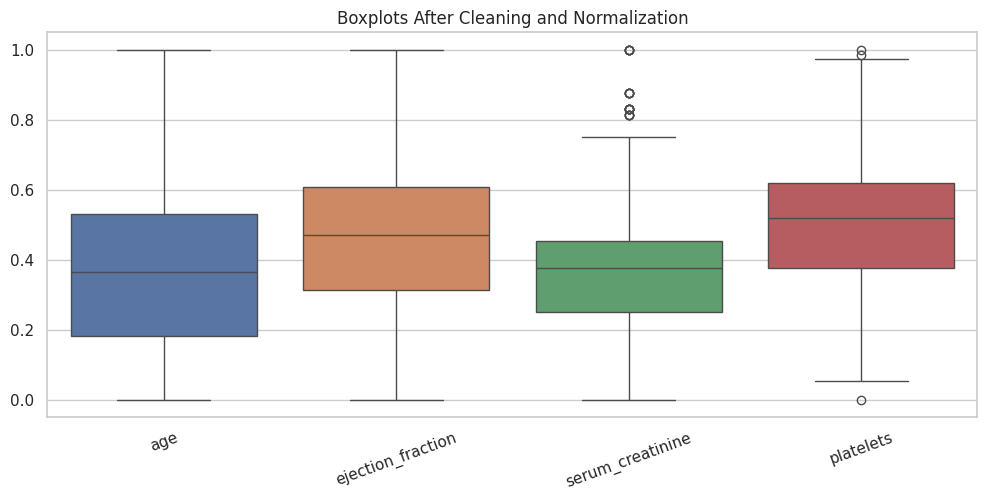

In [20]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df_clean[
        [
            "age",
            "ejection_fraction",
            "serum_creatinine",
            "platelets"
        ]
    ]
)

plt.title(
    "Boxplots After Cleaning and Normalization"
)

plt.xticks(rotation=20)

plt.show()

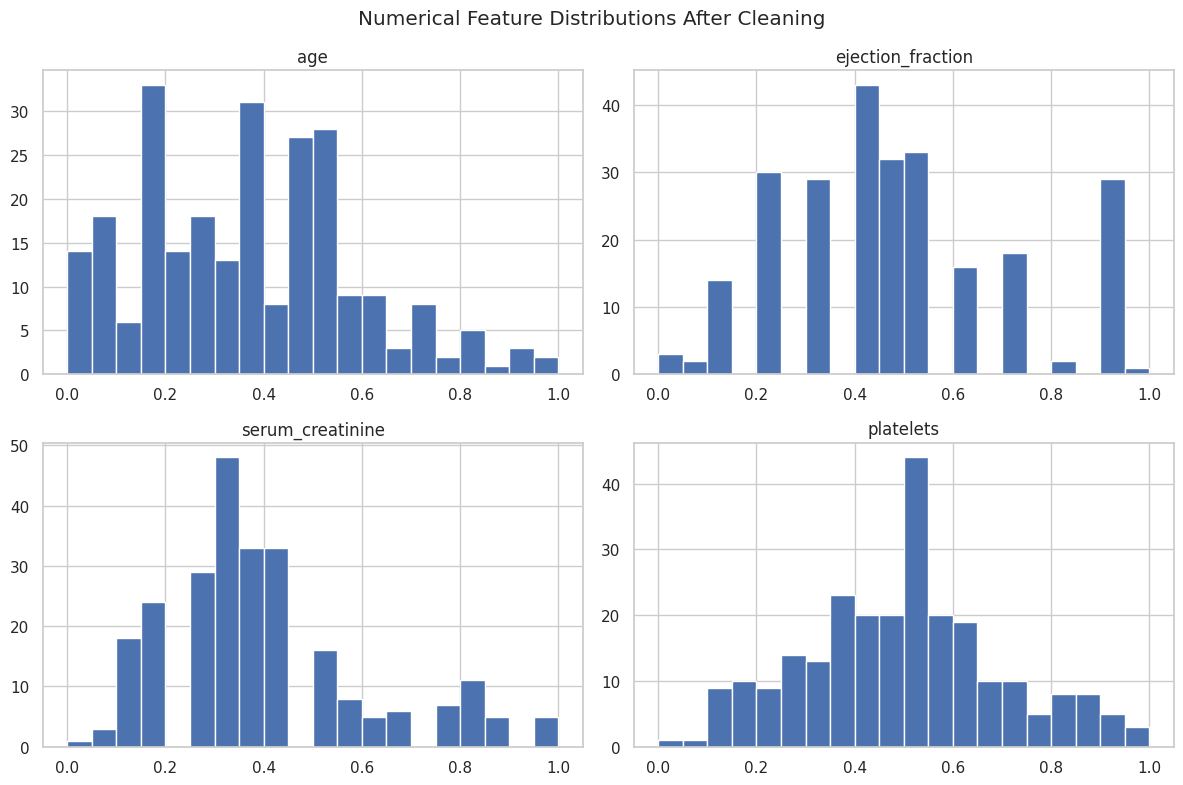

In [21]:
df_clean[
    [
        "age",
        "ejection_fraction",
        "serum_creatinine",
        "platelets"
    ]
].hist(
    figsize=(12, 8),
    bins=20
)

plt.suptitle(
    "Numerical Feature Distributions After Cleaning"
)

plt.tight_layout()

plt.show()

Final Missing Value Check

In [22]:
final_missing = df_clean.isnull().sum()

print("Final Missing Values:")

display(final_missing)

total_missing = final_missing.sum()

print("\nTotal missing values:", total_missing)

if total_missing == 0:
    print("SUCCESS: No missing values remain.")
else:
    print("Some missing values remain. Check the columns above.")

Final Missing Values:


,0
age,0
anaemia,0
creatinine_phosphokinase,0
diabetes,0
ejection_fraction,0
high_blood_pressure,0
platelets,0
serum_creatinine,0
serum_sodium,0
sex,0



Total missing values: 0
SUCCESS: No missing values remain.


In [23]:
print("Final Cleaned Dataset")

print("Shape:", df_clean.shape)

display(df_clean.head(10))

Final Cleaned Dataset
Shape: (252, 17)


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT,risk_score,age_group_<40,age_group_40-60,age_group_>60
0,0.636364,0,0.070489,0,0.117647,1,0.523529,0.8750,0.485714,1,0.0,4,1,0.146341,0,0,1
1,0.272727,0,1.000000,0,0.470588,0,0.518700,0.3750,0.657143,1,0.0,6,1,0.250871,0,1,0
2,0.454545,0,0.014813,0,0.117647,0,0.220588,0.5000,0.457143,1,1.0,7,1,0.083624,0,0,1
3,0.181818,1,0.010344,0,0.117647,0,0.361765,0.8750,0.685714,1,0.0,7,1,0.146341,0,1,0
5,0.909091,1,0.002171,0,0.509804,1,0.344118,1.0000,0.542857,1,0.0,8,1,0.724739,0,0,1
6,0.636364,1,0.027583,0,0.019608,0,0.117647,0.4375,0.685714,1,0.0,10,1,0.012195,0,0,1
8,0.454545,0,0.016218,0,1.000000,0,0.518700,0.6250,0.714286,0,0.0,10,1,0.888502,0,0,1
9,0.727273,1,0.011876,0,0.411765,1,0.885294,0.3750,0.571429,1,1.0,10,1,0.219512,0,0,1
11,0.400000,0,0.025667,0,0.215686,1,0.488235,0.2500,0.771429,1,1.0,10,1,0.076655,0,0,1
12,0.090909,1,0.121440,0,0.313725,0,0.144118,0.3750,0.685714,1,0.0,11,1,0.167247,0,1,0


In [24]:
print("=" * 50)
print("       DATA CLEANING SUMMARY")
print("=" * 50)

print("Original number of rows:", rows_before)
print("Final number of rows:", len(df_clean))
print(
    "Rows removed as outliers:",
    rows_before - len(df_clean)
)

print("Final number of columns:", df_clean.shape[1])

print(
    "Final missing values:",
    int(df_clean.isnull().sum().sum())
)

print("=" * 50)
print("Data cleaning and enrichment completed successfully!")
print("=" * 50)

       DATA CLEANING SUMMARY
Original number of rows: 299
Final number of rows: 252
Rows removed as outliers: 47
Final number of columns: 17
Final missing values: 0
Data cleaning and enrichment completed successfully!


**Summary**

The Heart Failure Clinical Records Dataset was successfully cleaned and enriched using Python and pandas. Missing values were identified and handled using appropriate imputation methods, invalid entries were corrected, and outliers were removed using the IQR method. New features such as age group and risk score were created, categorical data was encoded, and numerical features were normalized using MinMaxScaler. Finally, the cleaned dataset was validated to ensure that no missing values remained. The experiment demonstrates how proper data cleaning and preprocessing can prepare clinical data for further analysis and machine learning applications in healthcare.